## Visualisasi WorldCloud 

File CSV dengan label sentimen berhasil dibaca.


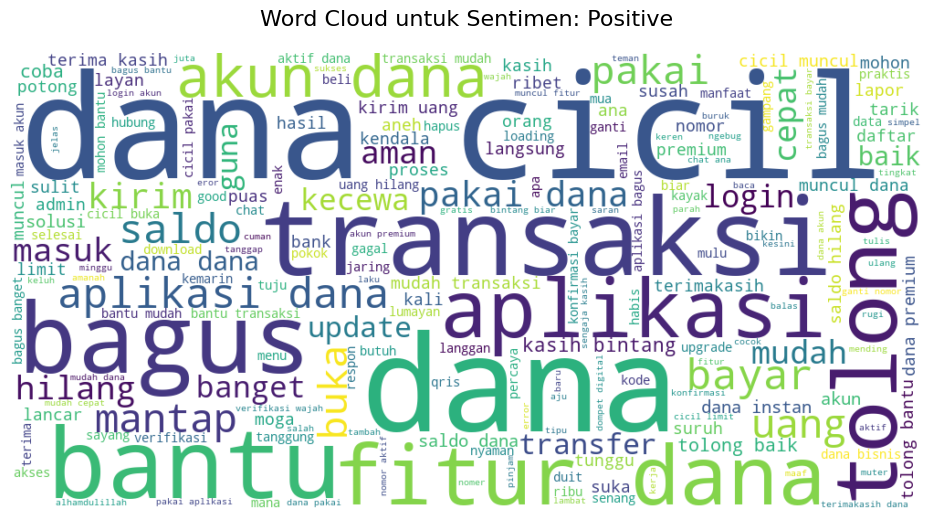

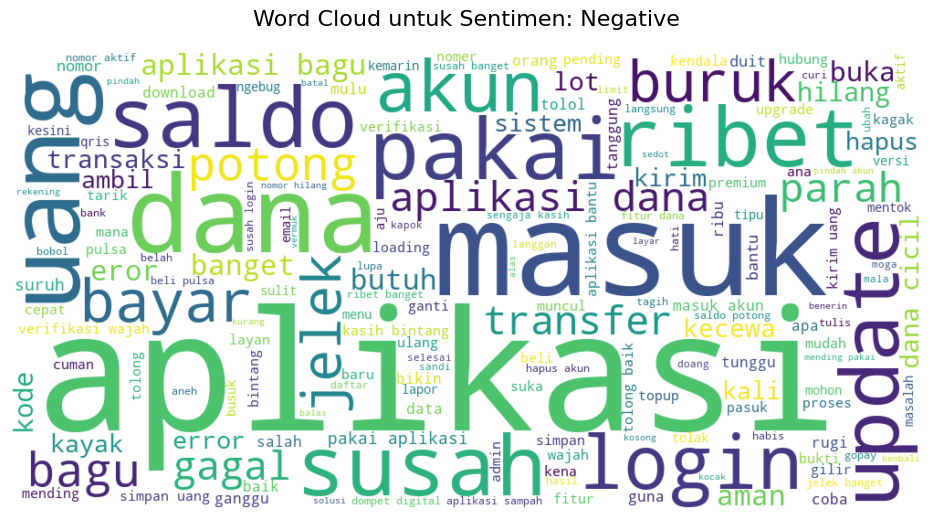

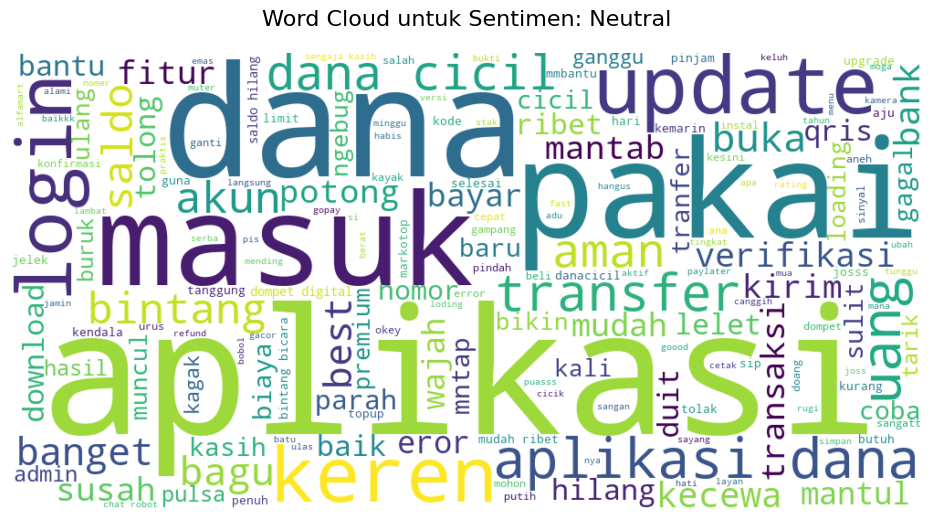

In [12]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- FUNGSI UNTUK MEMBUAT WORD CLOUD ---
def buat_wordcloud_sentimen(df, sentimen):
    """
    Fungsi untuk memfilter data berdasarkan sentimen dan membuat Word Cloud.
    - df: DataFrame yang berisi kolom 'steming_data' dan 'label'.
    - sentimen: String nama sentimen ('positive', 'negative', atau 'neutral').
    """
    # Filter DataFrame hanya untuk sentimen yang dipilih
    df_sentimen = df[df['label'] == sentimen]
    
    # Gabungkan semua teks dari data yang sudah difilter
    all_text = ' '.join(df_sentimen['steming_data'].astype(str))
    
    # Cek apakah ada teks untuk dibuat Word Cloud
    if not all_text.strip():
        print(f"Tidak ada data teks untuk sentimen '{sentimen}'. Word Cloud tidak dibuat.")
        return

    # Membuat objek WordCloud
    wordcloud = WordCloud(width=1000, height=500, background_color='white',
                          colormap='viridis', min_font_size=10).generate(all_text)

    # Menampilkan Word Cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    # Judul dinamis sesuai sentimen
    plt.title(f"Word Cloud untuk Sentimen: {sentimen.capitalize()}", fontsize=16, pad=20)
    plt.tight_layout(pad=0)
    plt.show()

# --- CONTOH PENGGUNAAN ---

try:
    # 1. Muat data yang sudah memiliki label sentimen
    # Pastikan file ini berisi kolom 'steming_data' dan 'label'
    data = pd.read_csv("../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv")
    print("File CSV dengan label sentimen berhasil dibaca.")

    # Pastikan tidak ada nilai kosong di kolom yang relevan
    data.dropna(subset=['steming_data', 'label'], inplace=True)
    
    # 2. Daftar sentimen yang ingin divisualisasikan
    daftar_sentimen = ['positive', 'negative', 'neutral']
    
    # 3. Buat Word Cloud untuk setiap sentimen dalam daftar
    for sentimen in daftar_sentimen:
        buat_wordcloud_sentimen(data, sentimen)

except FileNotFoundError:
    print("Error: File '../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv' tidak ditemukan.")
except KeyError:
    print("Error: Pastikan file CSV Anda memiliki kolom 'steming_data' dan 'label'.")

## Visualisasi N-Gram 

In [13]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

# Fungsi untuk mengekstrak dan membuat diagram N-gram
def plot_top_ngrams(corpus, title, n=20, ngram_range=(1, 1)):
    try:
        vectorizer = CountVectorizer(ngram_range=ngram_range).fit(corpus)
        bag_of_words = vectorizer.transform(corpus)
        sum_words = bag_of_words.sum(axis=0) 
        words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
        words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
        top_ngrams = words_freq[:n]
        
        df = pd.DataFrame(top_ngrams, columns=['Ngram', 'Frekuensi'])
        
        # --- Bagian Kode untuk Membuat Diagram ---
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Frekuensi', y='Ngram', data=df, palette='viridis')
        plt.title(title, fontsize=16)
        plt.xlabel('Frekuensi', fontsize=12)
        plt.ylabel('N-gram', fontsize=12)
        plt.show()
        
    except ValueError:
        print(f"Tidak ada data atau fitur yang cukup untuk membuat diagram untuk '{title}'.")

# --- BAGIAN UTAMA ---

# Muat data Anda yang sudah bersih
data = pd.read_csv("../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv")
data.dropna(subset=['steming_data'], inplace=True)
corpus = data['steming_data'].astype(str)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7584\3952293560.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Ngram', data=df, palette='viridis')
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the g

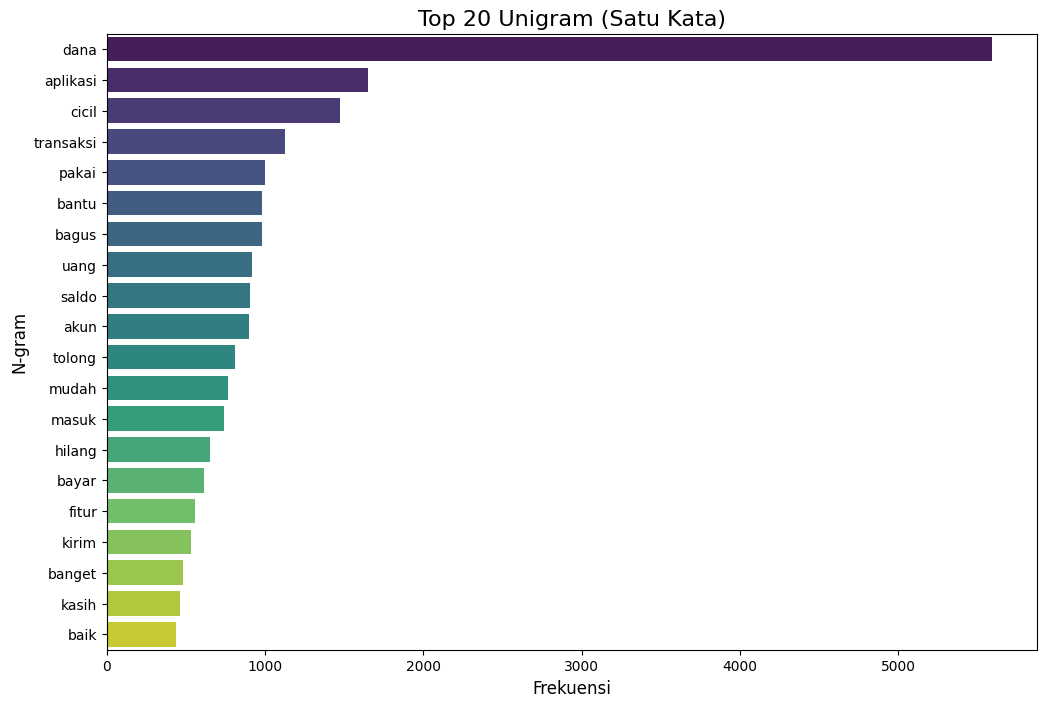

In [14]:
# 1. Panggil fungsi untuk membuat diagram UNIGRAM
plot_top_ngrams(corpus, title='Top 20 Unigram (Satu Kata)', n=20, ngram_range=(1, 1))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7584\3952293560.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Ngram', data=df, palette='viridis')
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the g

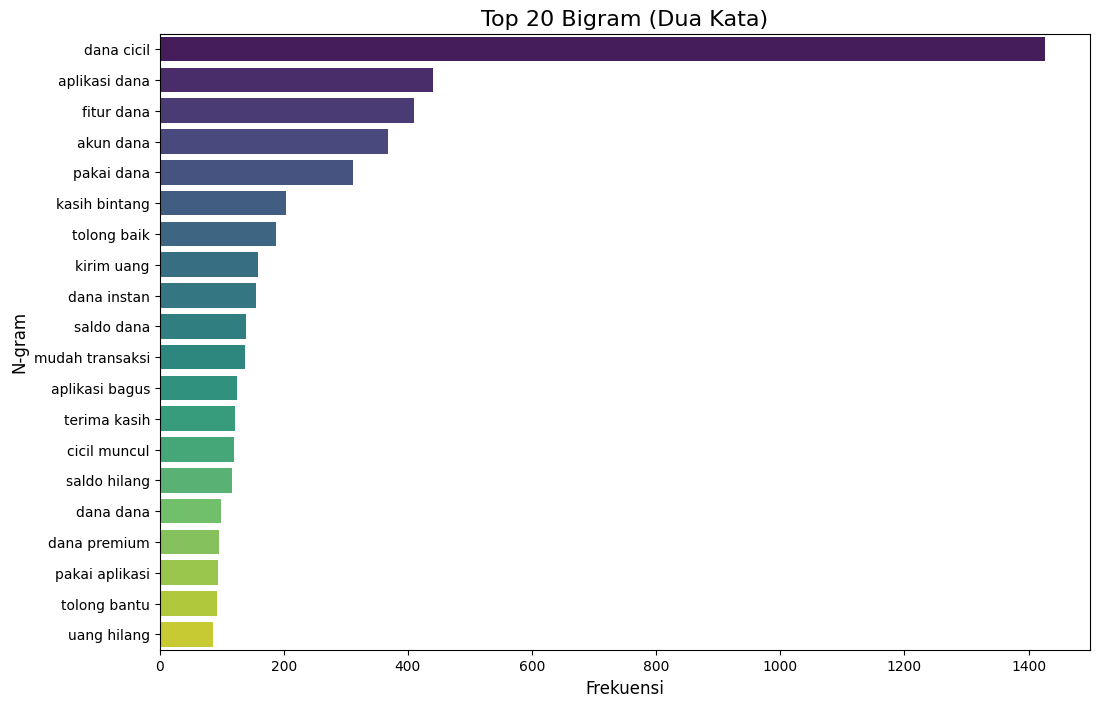

In [15]:
# 2. Panggil fungsi untuk membuat diagram BIGRAM
plot_top_ngrams(corpus, title='Top 20 Bigram (Dua Kata)', n=20, ngram_range=(2, 2))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7584\3952293560.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Ngram', data=df, palette='viridis')
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the g

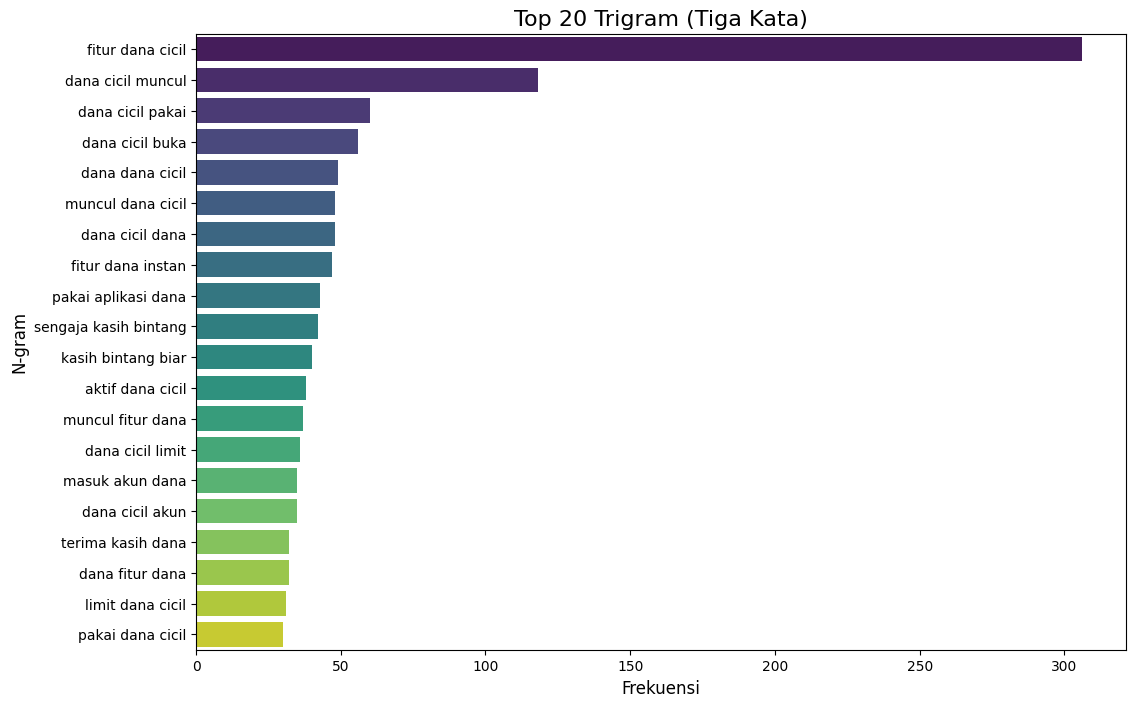

In [16]:
# 3. Panggil fungsi untuk membuat diagram TRIGRAM
plot_top_ngrams(corpus, title='Top 20 Trigram (Tiga Kata)', n=20, ngram_range=(3, 3))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7584\3952293560.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Ngram', data=df, palette='viridis')
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the g

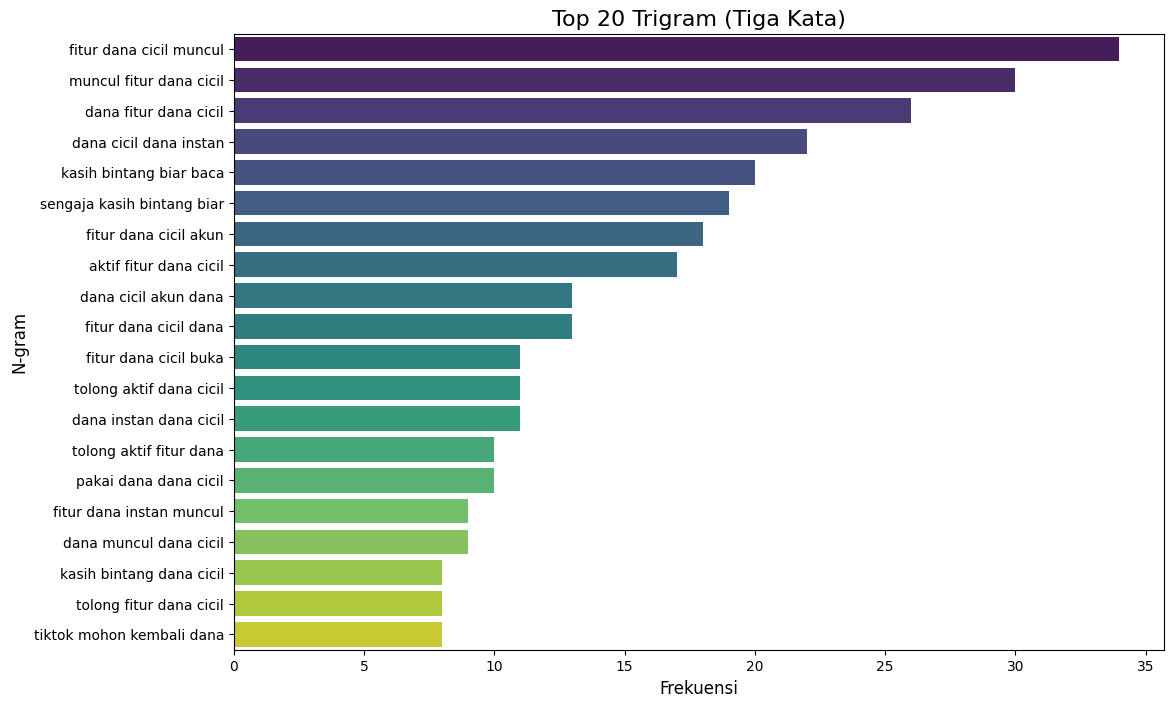

In [17]:
# 3. Panggil fungsi untuk membuat diagram TRIGRAM
plot_top_ngrams(corpus, title='Top 20 Trigram (Tiga Kata)', n=20, ngram_range=(4, 4))

## Visualisasi jumlah sentimen

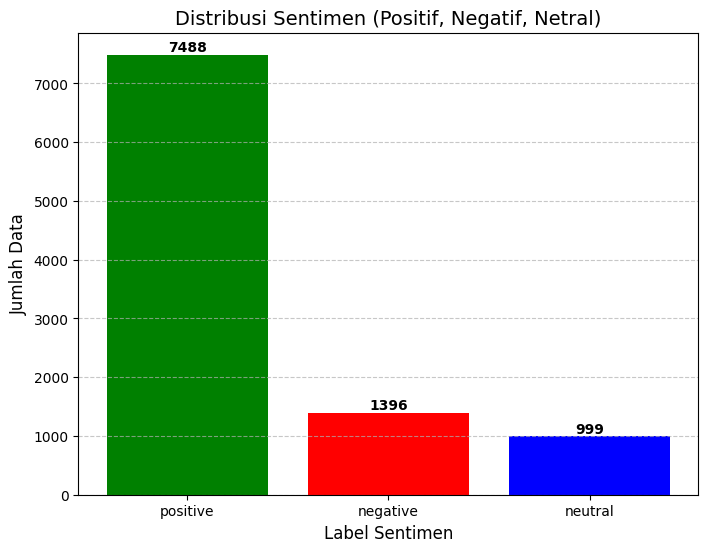

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd

data = pd.read_csv("../Pelabelan/PelabelanDana/DatasetPelabelanDana/Tahap5HasilPelabelan.csv")

# 1. Menghitung jumlah setiap sentimen
sentiment_counts = data['label'].value_counts()

# 2. Membuat Plot
plt.figure(figsize=(8, 6))

# Mengatur warna khusus (Opsional: Hijau=Positif, Merah=Negatif, Biru=Netral)
# Pastikan urutan warnanya sesuai dengan urutan index di sentiment_counts
colors = ['green' if x == 'positive' else 'red' if x == 'negative' else 'blue' for x in sentiment_counts.index]

# Plotting Bar Chart
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)

# 3. Menambahkan Label dan Judul
plt.title('Distribusi Sentimen (Positif, Negatif, Netral)', fontsize=14)
plt.xlabel('Label Sentimen', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)

# 4. Menambahkan angka di atas batang (Data Labels)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Menampilkan plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()